In [12]:
# if something is missing, you can install in a cell:
# %pip install pandas numpy scikit-learn statsmodels matplotlib

import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

def rmse(y_true, y_pred):
    from sklearn.metrics import mean_squared_error
    import numpy as np
    return np.sqrt(mean_squared_error(y_true, y_pred))


In [13]:
# put the CSV in the same folder as this notebook, or update the path
DATA_PATH = "hypertension_dataset.csv"

df = pd.read_csv(DATA_PATH)
df.shape, df.columns.tolist()

((174982, 23),
 ['Country',
  'Age',
  'BMI',
  'Cholesterol',
  'Systolic_BP',
  'Diastolic_BP',
  'Smoking_Status',
  'Alcohol_Intake',
  'Physical_Activity_Level',
  'Family_History',
  'Diabetes',
  'Stress_Level',
  'Salt_Intake',
  'Sleep_Duration',
  'Heart_Rate',
  'LDL',
  'HDL',
  'Triglycerides',
  'Glucose',
  'Gender',
  'Education_Level',
  'Employment_Status',
  'Hypertension'])

In [14]:
# target = continuous variable so linear regression makes sense
TARGET_COL = "Systolic_BP"
assert TARGET_COL in df.columns, "TARGET_COL not in dataframe"

# split columns by dtype (simple heuristic)
cat_cols_auto = df.select_dtypes(include=["object"]).columns.tolist()
num_cols_auto = [c for c in df.select_dtypes(include=[np.number]).columns if c != TARGET_COL]

# you can customize these if needed:
CATEGORICAL_COLS = cat_cols_auto
NUMERIC_COLS = num_cols_auto

print("categorical:", CATEGORICAL_COLS[:8], "..." if len(CATEGORICAL_COLS)>8 else "")
print("numeric:", NUMERIC_COLS[:8], "..." if len(NUMERIC_COLS)>8 else "")

# keep only the columns we use and drop NAs (simple week-1 approach)
used_cols = [TARGET_COL] + CATEGORICAL_COLS + NUMERIC_COLS
work = df[used_cols].dropna(axis=0, how='any').copy()

X = work[CATEGORICAL_COLS + NUMERIC_COLS]
y = work[TARGET_COL]

X.shape, y.shape


categorical: ['Country', 'Smoking_Status', 'Physical_Activity_Level', 'Family_History', 'Diabetes', 'Gender', 'Education_Level', 'Employment_Status'] ...
numeric: ['Age', 'BMI', 'Cholesterol', 'Diastolic_BP', 'Alcohol_Intake', 'Stress_Level', 'Salt_Intake', 'Sleep_Duration'] ...


((174982, 22), (174982,))

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

In [16]:
# handle scikit-learn versions (sparse_output changed name in newer versions)
try:
    categorical = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    categorical = OneHotEncoder(handle_unknown='ignore', sparse=False)

numeric = StandardScaler(with_mean=True, with_std=True)

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical, CATEGORICAL_COLS),
        ('num', numeric, NUMERIC_COLS),
    ]
)


In [17]:
baseline_model.fit(X_train, y_train)
y_pred_base = baseline_model.predict(X_test)

print("Baseline R2:", round(r2_score(y_test, y_pred_base), 3))
print("Baseline RMSE:", round(rmse(y_test, y_pred_base), 3))
print("Baseline MAE:", round(mean_absolute_error(y_test, y_pred_base), 3))

# CV: use neg_mean_squared_error, then sqrt and take mean
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_r2 = cross_val_score(baseline_model, X, y, cv=cv, scoring='r2')
cv_mse = -cross_val_score(baseline_model, X, y, cv=cv, scoring='neg_mean_squared_error')

cv_rmse = np.sqrt(cv_mse)  # per-fold RMSE
print("CV R2 mean±std:", f"{cv_r2.mean():.3f} ± {cv_r2.std():.3f}")
print("CV RMSE mean±std:", f"{cv_rmse.mean():.3f} ± {cv_rmse.std():.3f}")

Baseline R2: -0.0
Baseline RMSE: 26.097
Baseline MAE: 22.623
CV R2 mean±std: -0.000 ± 0.000
CV RMSE mean±std: 26.024 ± 0.056


In [18]:
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)

poly_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical, CATEGORICAL_COLS),
        ('num', Pipeline([('scaler', numeric),
                          ('poly', poly)]), NUMERIC_COLS),
    ]
)

poly_model = Pipeline(steps=[
    ('prep', poly_preprocessor),
    ('linreg', LinearRegression())
])

poly_model.fit(X_train, y_train)
y_pred_poly = poly_model.predict(X_test)

print("Poly R2:", round(r2_score(y_test, y_pred_poly), 3))
print("Poly RMSE:", round(rmse(y_test, y_pred_poly), 3))
print("Poly MAE:", round(mean_absolute_error(y_test, y_pred_poly), 3))

Poly R2: -0.001
Poly RMSE: 26.102
Poly MAE: 22.627


In [19]:
# build dense design matrix from the fitted preprocessor, with readable names
def design_matrix(preprocessor, X_data):
    Z = preprocessor.transform(X_data)
    try:
        names = []
        if CATEGORICAL_COLS:
            ohe = preprocessor.named_transformers_['cat']
            names.extend(list(ohe.get_feature_names_out(CATEGORICAL_COLS)))
        if NUMERIC_COLS:
            num_pipe = preprocessor.named_transformers_['num']
            if hasattr(num_pipe, 'named_steps') and 'poly' in num_pipe.named_steps:
                names.extend(list(num_pipe.named_steps['poly'].get_feature_names_out(NUMERIC_COLS)))
            else:
                names.extend(NUMERIC_COLS)
    except Exception:
        names = [f"f{i}" for i in range(Z.shape[1])]
    return pd.DataFrame(Z, columns=names, index=X_data.index)

# use the polynomial preprocessor here since that's where collinearity pops up more
Z_train = design_matrix(poly_preprocessor, X_train)

Z_wconst = sm.add_constant(Z_train, has_constant='add')
vif_df = pd.DataFrame({
    'feature': Z_wconst.columns,
    'VIF': [variance_inflation_factor(Z_wconst.values, i) for i in range(Z_wconst.shape[1])]
}).sort_values('VIF', ascending=False)

vif_df.head(25)  # top 25 highest VIF


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


,feature,VIF
7,Country_Germany,1.048104e+11
11,Country_Japan,9.050824e+10
8,Country_India,6.897470e+10
10,Country_Italy,4.966530e+10
19,Country_UK,2.208459e+10
14,Country_Saudi Arabia,3.525349e+09
5,Country_China,2.637565e+09
3,Country_Brazil,1.495072e+09
2,Country_Australia,4.759170e+08
1,Country_Argentina,4.354605e+08


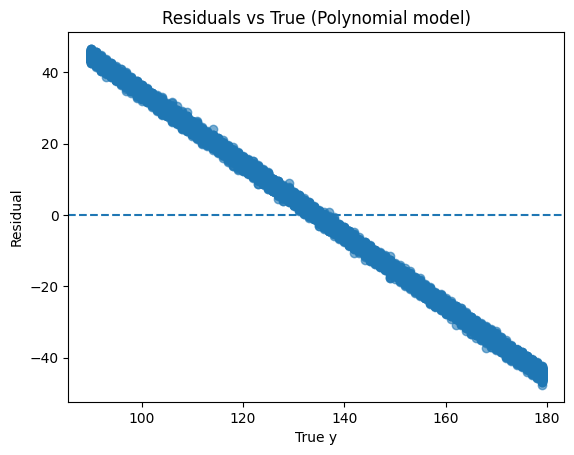

In [20]:
plt.figure()
plt.scatter(y_test, y_pred_poly - y_test, alpha=0.6)
plt.axhline(0, linestyle='--')
plt.title('Residuals vs True (Polynomial model)')
plt.xlabel('True y')
plt.ylabel('Residual')
plt.show()


In [21]:
notes = {
    "overfitting_controls": [
        "used 5-fold CV; kept polynomial degree at 2; scaled numeric features"
    ],
    "metrics": [
        "reported R2, RMSE, MAE; compared baseline vs polynomial"
    ],
    "expected_vs_unexpected": [
        "fill after you see results: e.g., 'poly helped a little; interactions with Age and BMI mattered' or 'no gain (probably noise/collinearity)'"
    ],
    "eda_links": [
        "connect to simple EDA patterns: e.g., Systolic_BP higher with Age/Cholesterol; check distributions/outliers"
    ],
    "next_steps_week2": [
        "try Ridge/Lasso/ElasticNet to handle multicollinearity instead of dropping features manually"
    ]
}
for k,v in notes.items():
    print(k.upper()+":")
    for item in v:
        print("-", item)
    print()


OVERFITTING_CONTROLS:
- used 5-fold CV; kept polynomial degree at 2; scaled numeric features

METRICS:
- reported R2, RMSE, MAE; compared baseline vs polynomial

EXPECTED_VS_UNEXPECTED:
- fill after you see results: e.g., 'poly helped a little; interactions with Age and BMI mattered' or 'no gain (probably noise/collinearity)'

EDA_LINKS:
- connect to simple EDA patterns: e.g., Systolic_BP higher with Age/Cholesterol; check distributions/outliers

NEXT_STEPS_WEEK2:
- try Ridge/Lasso/ElasticNet to handle multicollinearity instead of dropping features manually

